# SmartRouter & ModelPipeline: Production API Coverage
# SmartRouter 与 ModelPipeline：生产 API 覆盖

This notebook is the API coverage map for common industrial forecasting workflows: model discovery, manual pipelines, automated routing, search/HPO, ensembles, uncertainty, covariates, panel data, visualization, updates, and persistence.

本教程覆盖常见工业预测流程的 API：模型发现、手动管道、自动路由、搜索/HPO、集成、不确定性、协变量、面板数据、可视化、更新和持久化。

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

def make_retail_demand(n_days=240, n_stores=1, start="2023-01-01"):
    rows = []
    for i in range(n_stores):
        rng = np.random.default_rng(100 + i)
        dates = pd.date_range(start, periods=n_days, freq="D")
        dow = dates.dayofweek.to_numpy()
        month = dates.month.to_numpy()
        holiday = ((dow >= 5) | rng.binomial(1, 0.04, n_days).astype(bool)).astype(int)
        promotion = rng.binomial(1, 0.14 + 0.06 * (dow >= 4), n_days).astype(int)
        price_index = 1.0 + 0.04 * np.sin(np.linspace(0, 5 * np.pi, n_days)) + rng.normal(0, 0.015, n_days)
        temperature = 18 + 10 * np.sin(np.linspace(-0.8, 2.8 * np.pi, n_days)) + rng.normal(0, 1.8, n_days)
        stockout = rng.binomial(1, 0.025, n_days)
        baseline = 120 + 18 * i
        weekly = np.where(dow < 5, 8, 28)
        seasonal = 16 * np.sin(2 * np.pi * np.arange(n_days) / 365.25 + i / 3)
        trend = 0.08 * np.arange(n_days)
        demand = (
            baseline + weekly + seasonal + trend
            + 34 * promotion + 22 * holiday
            + 0.9 * np.maximum(temperature - 20, 0)
            - 75 * (price_index - 1.0)
            - 45 * stockout
            + rng.normal(0, 7, n_days)
        )
        rows.append(pd.DataFrame({
            "date": dates,
            "store_id": f"store_{i + 1:02d}",
            "sales": np.maximum(demand, 1),
            "promotion": promotion,
            "holiday": holiday,
            "price_index": price_index,
            "temperature": temperature,
            "stockout": stockout,
            "month": month,
        }))
    return pd.concat(rows, ignore_index=True)

In [2]:
from pathlib import Path
from PipelineTS.pipeline import ModelPipeline, PipelineConfigs, SmartRouter
from pprint import pprint

data = make_retail_demand(n_days=240, n_stores=1).drop(columns=["store_id"])
train, valid = data.iloc[:-21].copy(), data.iloc[-21:].copy()
future_covariates = valid[["date", "promotion", "holiday"]].copy()

pprint(ModelPipeline.list_all_available_models())
# pprint(SmartRouter.list_all_available_models())

['auto_arima',
 'catboost',
 'chronos_2',
 'chronos_2_small',
 'chronos_2_synth',
 'd_linear',
 'deepar',
 'extra_forest',
 'gau',
 'gc_forest',
 'itransformer',
 'multi_output_model',
 'multi_step_model',
 'n_beats',
 'n_hits',
 'n_linear',
 'patch_rnn',
 'prophet',
 'random_forest',
 'regressor_chain',
 'srs_net',
 'stacking_rnn',
 'tcn',
 'tft',
 'tide',
 'time2vec',
 'transformer',
 'wide_gbrt',
 'xgboost']


In [3]:
pipe = ModelPipeline(
    time_col="date",
    target_col="sales",
    lags=14,
    known_covariates=["promotion", "holiday"],
    past_covariates=["temperature", "price_index", "stockout"],
    include_models="light",
    exclude_models=None,
    quantile=0.9,
    cv=2,
    time_limit=90,
)
pipe.fit(train, valid_data=valid)
pipe.leader_board_.head()


2026-05-11 21:42:47 - ModelPipeline - INFO - Accelerator: MPS
2026-05-11 21:42:47 - ModelPipeline - INFO - Time budget: 90s
2026-05-11 21:42:47 - ModelPipeline - INFO - Training 11 models: ['d_linear', 'itransformer', 'multi_output_model', 'multi_step_model', 'n_hits', 'n_linear', 'patch_rnn', 'random_forest', 'regressor_chain', 'tide', 'transformer']
2026-05-11 21:42:47 - ModelPipeline - INFO - [1/11] Fitting d_linear... | remaining 90s
2026-05-11 21:42:51 - ModelPipeline - INFO -   => d_linear: metric=15.779071, train=3.94s, eval=0.02s, quantile_acc=1.000
2026-05-11 21:42:51 - ModelPipeline - INFO - [2/11] Fitting itransformer... | remaining 86s
2026-05-11 21:42:56 - ModelPipeline - INFO -   => itransformer: metric=18.172134, train=4.47s, eval=0.01s, quantile_acc=1.000
2026-05-11 21:42:56 - ModelPipeline - INFO - [3/11] Fitting multi_output_model... | remaining 82s
2026-05-11 21:42:59 - ModelPipeline - INFO -   => multi_output_model: metric=17.276306, train=3.22s, eval=0.21s, quanti

Leaderboard,model,train_cost(s),eval_cost(s),metric,quantile_acc
0,d_linear,3.93558,0.023335,15.779071,1.0
1,tide,4.086232,0.020028,16.506457,1.0
2,n_linear,3.581172,0.021471,16.54111,0.952381
3,multi_step_model,1.249808,0.201009,17.03252,1.0
4,multi_output_model,3.215227,0.205386,17.276306,1.0


In [4]:
print("Best model configs:")
print(pipe.get_model_all_configs())
print("Failures:", pipe.failed_models)
print("Skipped:", pipe.skipped_models)

pipe_pred = pipe.predict(21, future_covariates=future_covariates)
pipe_q = pipe.predict_quantiles(21, levels=[0.5, 0.8, 0.9], future_covariates=future_covariates)
display(pipe_pred.head())
display(pipe_q.head())

Best model configs:
{'model_configs': {'n_vars': 1, 'kernel_size': None, 'use_revin': True, 'dropout': 0.1, 'loss_fn': 'huber', 'learning_rate': 0.001, 'random_seed': 0, 'device': 'auto', 'weight_decay': 0.0001, 'channel_mixing': True, 'use_gtb': False, 'gtb_d_model': 64, 'routing_mode': 'static', 'in_features': 14, 'out_features': 14}, 'lags': 14, 'quantile': 0.9, 'time_col': 'date', 'target_col': 'sales', 'quantile_error': 0.23057907381550538, 'verbose': False, 'epochs': 1000, 'batch_size': 'auto', 'patience': 20, 'min_delta': 0, 'lr_scheduler': 'CosineAnnealingLR', 'lr_scheduler_patience': 10, 'lr_factor': 0.7, 'restore_best_weights': True, 'loss_type': 'min', 'use_ema': False, 'ema_decay': 0.999, 'use_swa': False, 'swa_start_frac': 0.75, 'warmup_epochs': 0, 'use_residual_gate': False, 'known_covariates': ['promotion', 'holiday'], 'past_covariates': ['temperature', 'price_index', 'stockout'], '_conformal_residuals': [0.03991246181923147, -0.196842799361161, 0.40739060339401467, 0.05

,date,sales,sales_lower,sales_upper
0,2023-08-08,152.956611,102.267698,206.495608
1,2023-08-09,158.550006,97.198471,193.547796
2,2023-08-10,153.445742,97.616930,188.444507
3,2023-08-11,149.211555,112.613781,185.809221
4,2023-08-12,172.288464,130.941738,246.159097


,date,sales,sales_q0.5_lower,sales_q0.5_upper,sales_q0.8_lower,sales_q0.8_upper,sales_q0.9_lower,sales_q0.9_upper
0,2023-08-08,152.956611,147.518701,169.412536,139.414654,181.884104,135.639896,192.390082
1,2023-08-09,158.550006,153.112096,175.005931,145.008049,187.477499,141.233291,197.983477
2,2023-08-10,153.445742,148.007832,169.901667,139.903784,182.373235,136.129027,192.879213
3,2023-08-11,149.211555,143.773645,165.667480,135.669598,178.139048,131.894840,188.645026
4,2023-08-12,172.288464,166.850554,188.744389,158.746506,201.215957,154.971748,211.721934


In [5]:
configs = PipelineConfigs([
    ("random_forest", "rf_business_lag", {
        "init_configs": {"n_estimators": 100, "max_depth": 10, "random_state": 42},
        "pipeline_configs": {"lags": 7, "scaler": None},
    }),
    ("extra_forest", "extra_long_lag", {
        "init_configs": {"n_estimators": 140, "max_depth": 12, "random_state": 42},
        "pipeline_configs": {"lags": 21, "scaler": True},
    }),
])

configured_pipe = ModelPipeline(
    time_col="date",
    target_col="sales",
    lags=14,
    include_models=["random_forest", "extra_forest"],
    configs=configs,
    quantile=0.9,
    cv=2,
)
configured_pipe.fit(train, valid_data=valid)
configured_pipe.leader_board_

,model_name,model_name_after_rename,model_configs
0,extra_forest,extra_long_lag,"{'init_configs': {'n_estimators': 140, 'max_depth': 12, 'random_state': 42}, 'pipeline_configs': {'lags': 21, 'scaler': True}, 'fit_configs': {}, 'predict_configs': {}}"
1,random_forest,rf_business_lag,"{'init_configs': {'n_estimators': 100, 'max_depth': 10, 'random_state': 42}, 'pipeline_configs': {'lags': 7, 'scaler': None}, 'fit_configs': {}, 'predict_configs': {}}"



2026-05-11 21:43:51 - ModelPipeline - INFO - Accelerator: MPS
2026-05-11 21:43:51 - ModelPipeline - INFO - Training 2 models: ['extra_long_lag', 'rf_business_lag']
2026-05-11 21:43:51 - ModelPipeline - INFO - Per-model pipeline_configs: extra_long_lag(lags=21, scaler=True); rf_business_lag(lags=7, scaler=None)
2026-05-11 21:43:51 - ModelPipeline - INFO - [1/2] Fitting extra_long_lag...
2026-05-11 21:43:57 - ModelPipeline - INFO -   => extra_long_lag: metric=18.852959, train=5.80s, eval=0.61s, quantile_acc=1.000
2026-05-11 21:43:57 - ModelPipeline - INFO - [2/2] Fitting rf_business_lag...
2026-05-11 21:44:03 - ModelPipeline - INFO -   => rf_business_lag: metric=16.613770, train=3.60s, eval=2.76s
2026-05-11 21:44:03 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (12.8s total)
2026-05-11 21:44:03 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric     QAcc 
  ----------------------------------------------

Leaderboard,model,train_cost(s),eval_cost(s),metric,quantile_acc
0,rf_business_lag,3.600996,2.763221,16.61377,None
1,extra_long_lag,5.803126,0.606187,18.852959,1.0


In [6]:
router = SmartRouter(
    time_col="date",
    target_col="sales",
    known_covariates=["promotion", "holiday"],
    past_covariates=["temperature", "price_index", "stockout"],
    preset="medium_quality",
    include_models=["random_forest", "extra_forest", "multi_output_model", "multi_step_model"],
    max_models=4,
    cv=2,
    search_strategy="auto",
    ensemble_strategy="auto",
    ensemble_top_k=3,
    hpo_strategy="auto",
    hpo_n_trials=5,
    hpo_timeout_per_model=20,
    quantile=0.9,
    time_limit=120,
)
router.fit(train, valid_data=valid)
router.leader_board_


2026-05-11 21:44:03 - SmartRouter - INFO - Preset 'medium_quality': max_models=4, cv=2, search=auto, ensemble=auto
2026-05-11 21:44:03 - SmartRouter - INFO - Accelerator: MPS
2026-05-11 21:44:03 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-05-11 21:44:03 - SmartRouter - INFO -   [RouteStep 1/5] 📊 Data Profiling                   0.0s
2026-05-11 21:44:03 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-05-11 21:44:03 - SmartRouter - INFO -   Rows: 219  |  Freq: D  |  Regular: True
  Stationarity: difference_stationary (d=1)
  Trend: 0.006  |  Seasonality: 0.375  |  Noise: 0.997
  Autocorr(1): 0.198  |  Autocorr(2): -0.228  |  CV: 0.152
  Seasonalities: 3  |  Regime changes: 83
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [7, 3, 4]
2026-05-11 21:44:03 - SmartRouter - INFO -   Data insights: completeness=100.0%, regularity=100.0%, duplicate_ts=0.0%, zeros=0.0%, entropy=0.7

Leaderboard,model,train_cost(s),eval_cost(s),metric,quantile_acc
0,extra_forest,3.256601,2.835382,13.446913,0.809524
1,random_forest,3.600172,2.838143,13.500353,0.809524
2,multi_output_model,1.30446,0.09735,21.521698,0.952381
3,multi_step_model,1.132815,0.098137,21.980756,0.952381


In [7]:
print("Selected strategy:")
print(router.strategy_)
print("Data profile:")
print(router.profile_)
print("Data insights:")
print(router.insights_)
print("Autonomy summary:")
router.autonomy_summary_

Selected strategy:
{'preprocessing': [], 'models': ['random_forest', 'extra_forest', 'multi_output_model', 'multi_step_model'], 'lags': 7, 'scaler': MinMaxScaler(), 'gbdt_differential_n': 1, 'feature_engineering': {'routing_mode': 'adaptive', 'prophet_use_lag_features': False, 'prophet_seasonality_mode': 'auto'}, 'model_hyperparams': {'d_linear__routing_mode': 'adaptive', 'n_linear__routing_mode': 'adaptive', 'n_beats__routing_mode': 'adaptive', 'n_hits__routing_mode': 'adaptive', 'tcn__routing_mode': 'adaptive', 'tft__routing_mode': 'adaptive', 'gau__routing_mode': 'adaptive', 'stacking_rnn__routing_mode': 'adaptive', 'time2vec__routing_mode': 'adaptive', 'transformer__routing_mode': 'adaptive', 'tide__routing_mode': 'adaptive', 'patch_rnn__routing_mode': 'adaptive', 'd_linear__use_gtb': True, 'n_linear__use_gtb': True, 'n_beats__use_gtb': True, 'n_hits__use_gtb': True, 'tcn__use_gtb': True, 'tft__use_gtb': True, 'gau__use_gtb': True, 'stacking_rnn__use_gtb': True, 'time2vec__use_gtb'

{'model_selection': ['random_forest',
  'extra_forest',
  'multi_output_model',
  'multi_step_model'],
 'lag_selection': 7,
 'preprocessing': [],
 'scaler': 'MinMaxScaler',
 'feature_engineering': {'routing_mode': 'adaptive',
  'prophet_use_lag_features': False,
  'prophet_seasonality_mode': 'auto'},
 'adaptive_hyperparams_count': 115,
 'adaptive_hyperparams_enabled': True,
 'hpo_requested_strategy': 'auto',
 'hpo_strategy': 'none',
 'hpo_enabled': False,
 'hpo_tuned_models': [],
 'nn_enhancements_enabled': True,
 'nn_enhancements': {'d_linear': {'routing_mode': 'adaptive',
   'use_gtb': True,
   'use_residual_gate': True},
  'n_linear': {'routing_mode': 'adaptive',
   'use_gtb': True,
   'use_residual_gate': True},
  'n_beats': {'routing_mode': 'adaptive',
   'use_gtb': True,
   'use_ema': True,
   'ema_decay': 0.999,
   'use_swa': True,
   'swa_start_frac': 0.75,
   'use_residual_gate': True},
  'n_hits': {'routing_mode': 'adaptive',
   'use_gtb': True,
   'use_ema': True,
   'ema_de

In [8]:
router_ensemble = router.predict(21)
router_forecast = router.predict(21, use_ensemble=False, future_covariates=future_covariates)
router_q = router.predict_quantiles(21, levels=[0.8, 0.9, 0.95], future_covariates=future_covariates)

display(router_ensemble.head())
display(router_forecast.head())
display(router_q.head())

,date,sales,sales_lower,sales_upper
0,2023-08-08,139.345264,107.253936,158.316404
1,2023-08-09,141.582910,109.491581,160.554050
2,2023-08-10,143.293678,111.202350,162.264818
3,2023-08-11,140.072603,107.981275,159.043743
4,2023-08-12,142.983211,110.891883,161.954351


,date,sales,sales_lower,sales_upper
0,2023-08-08,139.415764,107.324435,158.386904
1,2023-08-09,174.582620,142.491292,193.553760
2,2023-08-10,142.684993,110.593665,161.656133
3,2023-08-11,140.292375,108.201047,159.263515
4,2023-08-12,185.931586,153.840258,204.902726


,date,sales,sales_q0.8_lower,sales_q0.8_upper,sales_q0.9_lower,sales_q0.9_upper,sales_q0.95_lower,sales_q0.95_upper
0,2023-08-08,139.415764,121.007351,153.106544,107.324435,158.386904,97.016389,162.714897
1,2023-08-09,174.582620,156.174208,188.273401,142.491292,193.553760,132.183246,197.881753
2,2023-08-10,142.684993,124.276580,156.375774,110.593665,161.656133,100.285618,165.984126
3,2023-08-11,140.292375,121.883963,153.983156,108.201047,159.263515,97.893001,163.591508
4,2023-08-12,185.931586,167.523173,199.622367,153.840258,204.902726,143.532212,209.230719


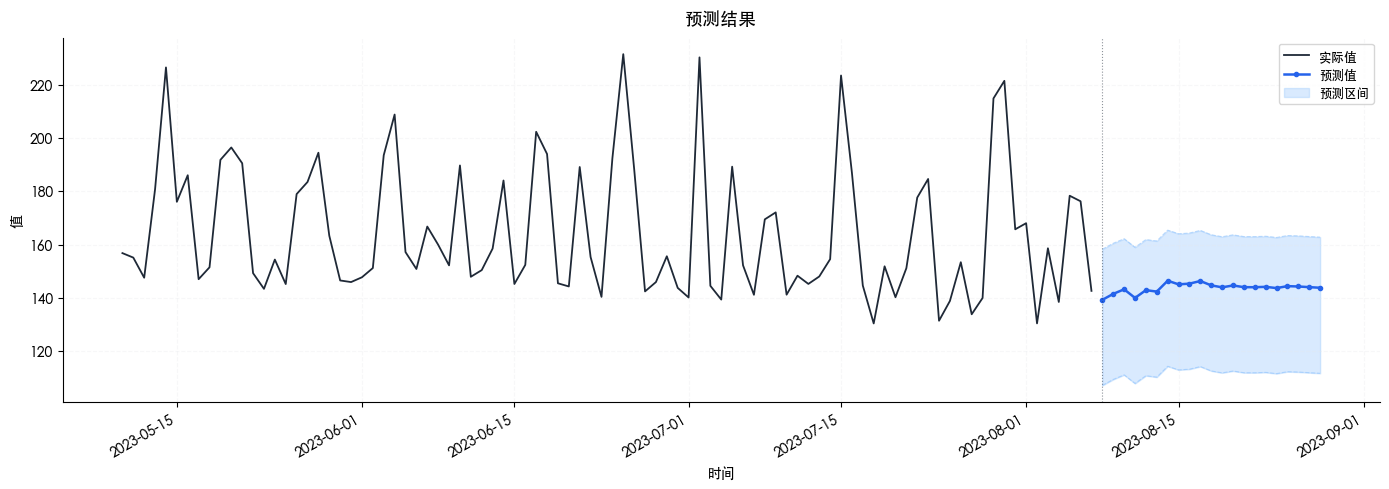

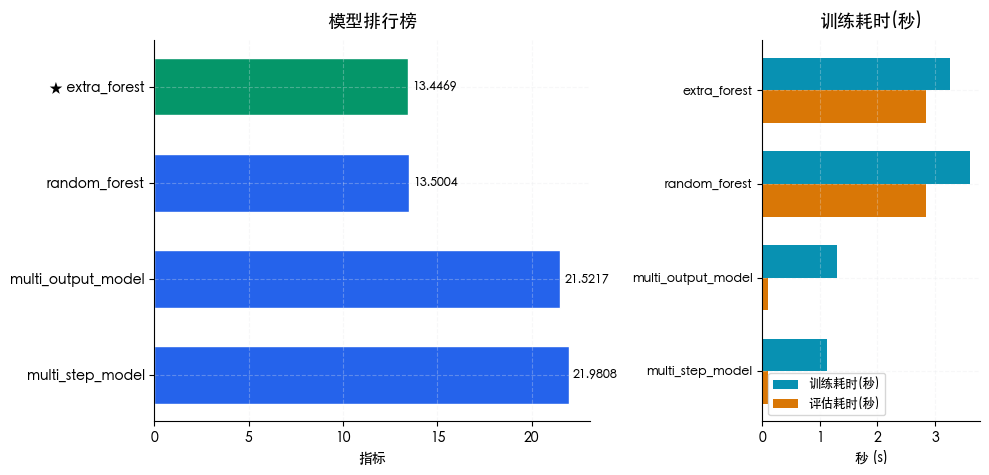

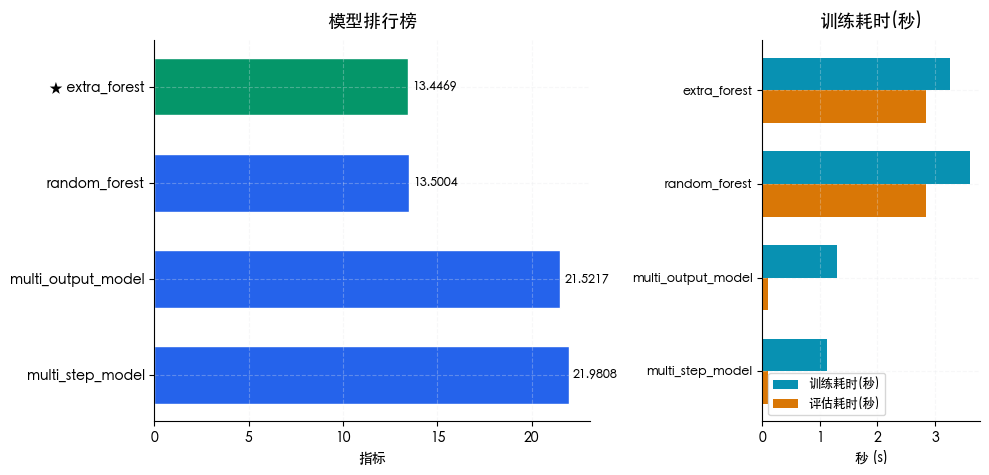

In [9]:
router.plot(n=21, history_tail=90, lang="zh")
router.plot_leaderboard(lang="zh")

In [10]:
path = "../tmp_router_prod.pts"
router.save(path, metadata={"scenario": "retail_production", "service": "forecasting"})
restored = SmartRouter.load(path)
restored.predict(7, future_covariates=future_covariates.head(7)).head()

,date,sales,sales_lower,sales_upper
0,2023-08-08,139.415764,107.324435,158.386904
1,2023-08-09,174.582620,142.491292,193.553760
2,2023-08-10,142.684993,110.593665,161.656133
3,2023-08-11,140.292375,108.201047,159.263515
4,2023-08-12,185.931586,153.840258,204.902726


In [11]:
new_observations = valid.copy()
router.update(new_observations, refit_all=False)
router.predict(7, future_covariates=future_covariates.head(7)).head()


2026-05-11 21:44:56 - ModelPipeline - INFO -   Updated: extra_forest


,date,sales,sales_lower,sales_upper
0,2023-08-29,149.934581,119.389341,167.670236
1,2023-08-30,173.358334,142.813094,191.093989
2,2023-08-31,148.380215,117.834976,166.115871
3,2023-09-01,145.873591,115.328352,163.609247
4,2023-09-02,193.698693,163.153454,211.434348


In [12]:
panel = make_retail_demand(n_days=160, n_stores=3)
panel_train = panel.groupby("store_id", group_keys=False).head(145).reset_index(drop=True)
panel_valid = panel.groupby("store_id", group_keys=False).tail(15).reset_index(drop=True)
panel_future = panel_valid[["date", "store_id", "promotion", "holiday"]]

panel_router = SmartRouter(
    time_col="date",
    target_col="sales",
    id_col="store_id",
    known_covariates=["promotion", "holiday"],
    past_covariates=["temperature", "price_index", "stockout"],
    preset="fast",
    include_models=["random_forest", "extra_forest", "multi_output_model"],
    quantile=0.9,
    time_limit=90,
)
panel_router.fit(panel_train, valid_data=panel_valid)
panel_router.predict(15, future_covariates=panel_future).head()


2026-05-11 21:44:57 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-05-11 21:44:57 - SmartRouter - INFO - Accelerator: MPS
2026-05-11 21:44:57 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-05-11 21:44:57 - SmartRouter - INFO -   [RouteStep 1/4] 📊 Data Profiling                   0.0s
2026-05-11 21:44:57 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-05-11 21:44:57 - SmartRouter - INFO -   Rows: 145  |  Freq: D  |  Regular: True
  Stationarity: non_stationary (d=1)
  Trend: 0.028  |  Seasonality: 0.446  |  Noise: 0.986
  Autocorr(1): 0.275  |  Autocorr(2): -0.228  |  CV: 0.148
  Seasonalities: 3  |  Regime changes: 66
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [7, 3, 4]
2026-05-11 21:44:57 - SmartRouter - INFO -   Data insights: completeness=100.0%, regularity=99.3%, duplicate_ts=0.0%, zeros=0.0%, entropy=0.6708266587944429, 

,date,sales,sales_lower,sales_upper,store_id
0,2023-05-26,147.233504,127.293157,165.431651,store_01
1,2023-05-27,182.214394,162.274048,200.412541,store_01
2,2023-05-28,185.116019,165.175672,203.314166,store_01
3,2023-05-29,150.589362,130.649015,168.787509,store_01
4,2023-05-30,150.637705,130.697358,168.835852,store_01
